In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import os
from IPython.display import Audio

def gravar_audio(nome_arquivo="minha_voz.wav"):
    # Interface HTML/JS para acessar o microfone do navegador
    js = Javascript('''
        async function recordAudio() {
            const div = document.createElement('div');
            const btn = document.createElement('button');
            btn.textContent = '🔴 Clique aqui para PARAR a gravação';
            btn.style.padding = '10px';
            btn.style.color = 'white';
            btn.style.background = 'red';
            btn.style.border = 'none';
            btn.style.cursor = 'pointer';

            div.appendChild(btn);
            document.body.appendChild(div);

            const stream = await navigator.mediaDevices.getUserMedia({audio:true});
            const mediaRecorder = new MediaRecorder(stream);
            const chunks = [];

            mediaRecorder.ondataavailable = e => chunks.push(e.data);

            let recordPromise = new Promise((resolve) => {
                btn.onclick = () => { mediaRecorder.stop(); };
                mediaRecorder.onstop = () => {
                    const blob = new Blob(chunks, {type: 'audio/webm'});
                    const reader = new FileReader();
                    reader.readAsDataURL(blob);
                    reader.onloadend = () => {
                        resolve(reader.result);
                        div.remove();
                        stream.getTracks().forEach(t => t.stop());
                    };
                };
            });

            mediaRecorder.start();
            return recordPromise;
        }
    ''')
    display(js)
    print("Gravando, clique no botão vermelho acima para parar.")

    # Recebe o áudio do navegador em base64
    audio_base64 = eval_js('recordAudio()')

    # Salva como um arquivo temporário webm
    b64 = audio_base64.split(',')[1]
    with open('temp.webm', 'wb') as f:
        f.write(b64decode(b64))

    # Usa o FFmpeg (nativo do Colab) para converter para WAV, Mono, 44.1kHz
    print(f"Convertendo para {nome_arquivo}...")
    os.system(f"ffmpeg -y -i temp.webm -ac 1 -ar 44100 {nome_arquivo} -loglevel quiet")
    os.remove('temp.webm')

    print("Gravação concluída e salva!")
    display(Audio(nome_arquivo))

# Executa a função
gravar_audio("minha_voz.wav")

<IPython.core.display.Javascript object>

Gravando, clique no botão vermelho acima para parar.
Convertendo para minha_voz.wav...
Gravação concluída e salva!


In [ ]:
import os
from google.colab import files
from IPython.display import Audio, display

print("Faça o upload de um arquivo de áudio (.mp3 ou .wav):")
uploaded = files.upload()
nome_arquivo_original = list(uploaded.keys())[0]

# O arquivo de destino será sempre 'minha_voz.wav' para conectar
# automaticamente com a próxima célula de processamento
arquivo_destino = "minha_voz.wav"

# Verifica se o arquivo precisa ser convertido de mp3 para wav
if nome_arquivo_original.lower().endswith('.mp3'):
    print(f"Convertendo '{nome_arquivo_original}' para WAV (Mono, 44.1kHz)...")
    # Usa o ffmpeg do Colab para converter o arquivo
    os.system(f"ffmpeg -y -i '{nome_arquivo_original}' -ac 1 -ar 44100 {arquivo_destino} -loglevel quiet")
    print("Conversão concluída!")

    # Remove o mp3 original para não ocupar espaço no Colab
    os.remove(nome_arquivo_original)

elif nome_arquivo_original.lower().endswith('.wav'):
    # Se já for wav, apenas renomeia para o padrão esperado
    os.rename(nome_arquivo_original, arquivo_destino)
    print("Arquivo WAV recebido.")
else:
    print("Formato não suportado. Por favor, envie um .mp3 ou .wav.")


print(f"\nArquivo '{arquivo_destino}' pronto para o processamento.")
display(Audio(arquivo_destino))

Faça o upload de um arquivo de áudio (.mp3 ou .wav):


Saving James Earl Jones On Being The Voice Of Darth Vader - American Film Institute (192k).mp3 to James Earl Jones On Being The Voice Of Darth Vader - American Film Institute (192k).mp3
Convertendo 'James Earl Jones On Being The Voice Of Darth Vader - American Film Institute (192k).mp3' para WAV (Mono, 44.1kHz)...
Conversão concluída!

🎧 Arquivo 'minha_voz.wav' pronto para o processamento.


In [ ]:
import numpy as np
import scipy.io.wavfile as wavfile
import scipy.signal as signal
import matplotlib.pyplot as plt
from IPython.display import Audio, display

filename = "minha_voz.wav"

try:
    fs, data = wavfile.read(filename)
except FileNotFoundError:
    print("Arquivo não encontrado. Execute a célula de gravação ou faça o upload primeiro!")
    raise

# ==========================================
# ETAPA 1: Carregamento e Normalização da Voz
# ==========================================
if len(data.shape) > 1:
    data = data.mean(axis=1)
max_in = np.max(np.abs(data))
if max_in > 0:
    data = data / max_in

print("🎧 ETAPA 1: Sua Voz Original")
display(Audio(data, rate=fs))

# ==========================================
# ETAPA 2: Filtro FIR Passa-Baixa (Janela de Hamming)
# ==========================================
freq_corte = 1600.0
num_taps = 101

# Projeto FIR em ponto flutuante
fir_coeffs = signal.firwin(num_taps, freq_corte, fs=fs, pass_zero='lowpass')

# Quantização Q15 (Fator 32768) para simular ponto fixo puro de 16 bits
fator_escala = 32768
fir_quantizado = np.round(fir_coeffs * fator_escala) / fator_escala

# Filtragem FIR (Sem feedback -> a = 1.0)
filtrado = signal.lfilter(fir_quantizado, 1.0, data)

max_filt = np.max(np.abs(filtrado))
if max_filt > 0:
    filtrado = filtrado / max_filt

print(f"\n🎧 ETAPA 2: Filtro FIR Passa-Baixa ({freq_corte} Hz, {num_taps} Taps)")
display(Audio(filtrado, rate=fs))

# ==========================================
# ETAPA 3: Saturação Suave (Soft Clipping / LUT)
# ==========================================
ganho_entrada = 2.0
saturado = np.tanh(filtrado * ganho_entrada)
ganho_saida = 0.6
saturado = saturado * ganho_saida

print("\n🎧 ETAPA 3: Saturação Suave")
display(Audio(saturado, rate=fs))

# ==========================================
# ETAPA 4: Efeito Capacete (Comb Filter / Buffer SRAM)
# ==========================================
atraso_ms = 25.0
amostras_atraso = int((atraso_ms / 1000.0) * fs)

capacete = np.copy(saturado)
capacete[amostras_atraso:] += 0.6 * saturado[:-amostras_atraso]

max_cap = np.max(np.abs(capacete))
if max_cap > 0:
    capacete = capacete / max_cap

print("\n🎧 ETAPA 4: Capacete Metálico")
display(Audio(capacete, rate=fs))

# ==========================================
# ETAPA 5: Pitch Down (Configuração do Codec I2C)
# ==========================================
taxa_vader = int(fs * 0.88)

print("\n🎧 ETAPA 5: ÁUDIO FINAL - Darth Vader")
display(Audio(capacete, rate=taxa_vader))

# ==========================================
# GERAÇÃO DOS GRÁFICOS (Espectro em Frequência)
# ==========================================
N = len(data)
freqs = np.fft.fftfreq(N, 1 / fs)[:N // 2]

def calc_db(sinal):
    fft_vals = np.abs(np.fft.fft(sinal))[:N // 2]
    return 20 * np.log10(fft_vals + 1e-10)

plt.figure(figsize=(12, 9))

# 1. Espectro Original
plt.subplot(3, 1, 1)
plt.plot(freqs, calc_db(data), color='blue', alpha=0.7)
plt.title("1. Espectro de Frequência - Voz Original")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 4000)
plt.grid(True)

# 2. Espectro Filtrado (FIR Passa-Baixa)
plt.subplot(3, 1, 2)
plt.plot(freqs, calc_db(filtrado), color='darkred', alpha=0.7)
plt.title(f"2. Filtro FIR Passa-Baixa ({freq_corte} Hz, {num_taps} Taps - Q15)")
plt.axvline(x=freq_corte, color='black', linestyle='--', label=f'Corte Passa-Baixa ({freq_corte} Hz)')
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 4000)
plt.legend()
plt.grid(True)

# 3. Espectro Final Processado
plt.subplot(3, 1, 3)
plt.plot(freqs, calc_db(capacete), color='purple', alpha=0.7)
plt.title("3. Espectro Final (Saturação + Ressonância do Capacete)")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 4000)
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# ETAPA 6: Exportação dos Coeficientes para o Verilog
# ==========================================
fir_int16 = np.round(fir_coeffs * fator_escala).astype(int)

print("\n" + "="*60)
print("  CONSTANTES DO FILTRO FIR PARA O FPGA (Q15 / 16-BITS)   ")
print("="*60)
print(f"// Filtro FIR Passa-Baixa: {num_taps} coeficientes")
print(f"const int16_t fir_vader_taps[{num_taps}] = {{")
# Imprime 8 coeficientes por linha para facilitar a visualização no código C/Verilog
for i in range(0, num_taps, 8):
    linha = ", ".join(map(str, fir_int16[i:i+8]))
    virgula = "," if i + 8 < num_taps else ""
    print(f"    {linha}{virgula}")
print("};")

Arquivo não encontrado. Execute a célula de gravação ou faça o upload primeiro!


FileNotFoundError: [Errno 2] No such file or directory: 'minha_voz.wav'

🎧 ETAPA 1: Sua Voz Original



🎧 ETAPA 2: Filtro FIR Passa-Alta (600.0 Hz, 101 Taps - Sem Graves)



🎧 ETAPA 3: ÁUDIO FINAL - Efeito Hélio


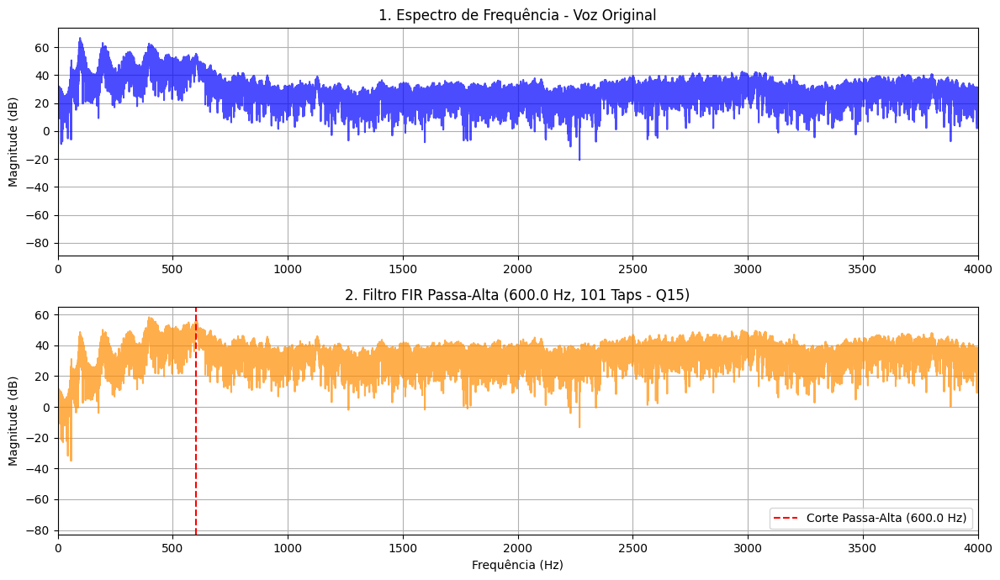


  CONSTANTES DO FILTRO FIR HÉLIO PARA O FPGA (Q15 / 16-BITS) 
// Filtro FIR Passa-Alta: 101 coeficientes
const int16_t fir_helio_taps[101] = {
    15, 15, 15, 15, 15, 15, 15, 15,
    15, 14, 12, 9, 6, 1, -5, -12,
    -21, -32, -44, -59, -75, -94, -115, -138,
    -163, -190, -219, -250, -283, -317, -352, -389,
    -426, -464, -502, -540, -578, -614, -650, -685,
    -717, -748, -777, -802, -825, -845, -861, -874,
    -884, -889, 31862, -889, -884, -874, -861, -845,
    -825, -802, -777, -748, -717, -685, -650, -614,
    -578, -540, -502, -464, -426, -389, -352, -317,
    -283, -250, -219, -190, -163, -138, -115, -94,
    -75, -59, -44, -32, -21, -12, -5, 1,
    6, 9, 12, 14, 15, 15, 15, 15,
    15, 15, 15, 15, 15
};


In [ ]:
import numpy as np
import scipy.io.wavfile as wavfile
import scipy.signal as signal
import matplotlib.pyplot as plt
from IPython.display import Audio, display

filename = "minha_voz.wav"

try:
    fs, data = wavfile.read(filename)
except FileNotFoundError:
    print("Arquivo não encontrado. Execute a célula de gravação ou faça o upload primeiro!")
    raise

# ==========================================
# ETAPA 1: Carregamento e Normalização da Voz
# ==========================================
if len(data.shape) > 1:
    data = data.mean(axis=1)
max_in = np.max(np.abs(data))
if max_in > 0:
    data = data / max_in

print("🎧 ETAPA 1: Sua Voz Original")
display(Audio(data, rate=fs))

# ==========================================
# ETAPA 2: Filtro FIR Passa-Alta (Janela de Hamming)
# ==========================================
freq_corte = 600.0
# Nota: num_taps DEVE ser ímpar para filtros passa-alta (Filtro Tipo I, permitindo ganho em Nyquist)
num_taps = 101

# Projeto FIR em ponto flutuante
fir_coeffs = signal.firwin(num_taps, freq_corte, fs=fs, pass_zero=False)

# Quantização Q15 (Fator 32768) para ponto fixo de 16 bits sem risco de overflow
fator_escala = 32768
fir_quantizado = np.round(fir_coeffs * fator_escala) / fator_escala

# Filtragem FIR direta (sem realimentação -> a = 1.0)
filtrado = signal.lfilter(fir_quantizado, 1.0, data)

max_filt = np.max(np.abs(filtrado))
if max_filt > 0:
    filtrado = filtrado / max_filt

print(f"\n🎧 ETAPA 2: Filtro FIR Passa-Alta ({freq_corte} Hz, {num_taps} Taps - Sem Graves)")
display(Audio(filtrado, rate=fs))

# ==========================================
# ETAPA 3: Pitch Up (Aceleração de Clock do Codec WM8731)
# ==========================================
taxa_helio = int(fs * 1.80)

print("\n🎧 ETAPA 3: ÁUDIO FINAL - Efeito Hélio")
display(Audio(filtrado, rate=taxa_helio))

# ==========================================
# GERAÇÃO DOS GRÁFICOS (Espectro em Frequência)
# ==========================================
N = len(data)
freqs = np.fft.fftfreq(N, 1 / fs)[:N // 2]

def calc_db(sinal):
    fft_vals = np.abs(np.fft.fft(sinal))[:N // 2]
    return 20 * np.log10(fft_vals + 1e-10)

plt.figure(figsize=(12, 7))

# 1. Espectro Original
plt.subplot(2, 1, 1)
plt.plot(freqs, calc_db(data), color='blue', alpha=0.7)
plt.title("1. Espectro de Frequência - Voz Original")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 4000)
plt.grid(True)

# 2. Espectro Filtrado (FIR Passa-Alta)
plt.subplot(2, 1, 2)
plt.plot(freqs, calc_db(filtrado), color='darkorange', alpha=0.7)
plt.title(f"2. Filtro FIR Passa-Alta ({freq_corte} Hz, {num_taps} Taps - Q15)")
plt.axvline(x=freq_corte, color='red', linestyle='--', label=f'Corte Passa-Alta ({freq_corte} Hz)')
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 4000)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# ETAPA 4: Exportação dos Coeficientes para o Verilog
# ==========================================
fir_int16 = np.round(fir_coeffs * fator_escala).astype(int)

print("\n" + "="*60)
print("  CONSTANTES DO FILTRO FIR HÉLIO PARA O FPGA (Q15 / 16-BITS) ")
print("="*60)
print(f"// Filtro FIR Passa-Alta: {num_taps} coeficientes")
print(f"const int16_t fir_helio_taps[{num_taps}] = {{")
for i in range(0, num_taps, 8):
    linha = ", ".join(map(str, fir_int16[i:i+8]))
    virgula = "," if i + 8 < num_taps else ""
    print(f"    {linha}{virgula}")
print("};")

🎧 SINAL BASE: Sine Sweep Puro (20.0 Hz -> 4000.0 Hz)



             PIPELINE 1: DARTH VADER (101 TAPS)                 

🎧 VADER - Etapa 2: Passa-Baixa (Som silencia ao cruzar 1600 Hz)



🎧 VADER - Etapa 3: Saturação Suave (Harmônicos mecânicos)



🎧 VADER - Etapa 4: Efeito Capacete (Cancelamento de fase periódico)



🎧 VADER - Etapa 5: Áudio Final Processado



               PIPELINE 2: HÉLIO (101 TAPS)                     

🎧 HÉLIO - Etapa 2: Passa-Alta (Grave mudo; som surge a partir de 600 Hz)



🎧 HÉLIO - Etapa 3: Áudio Final Processado


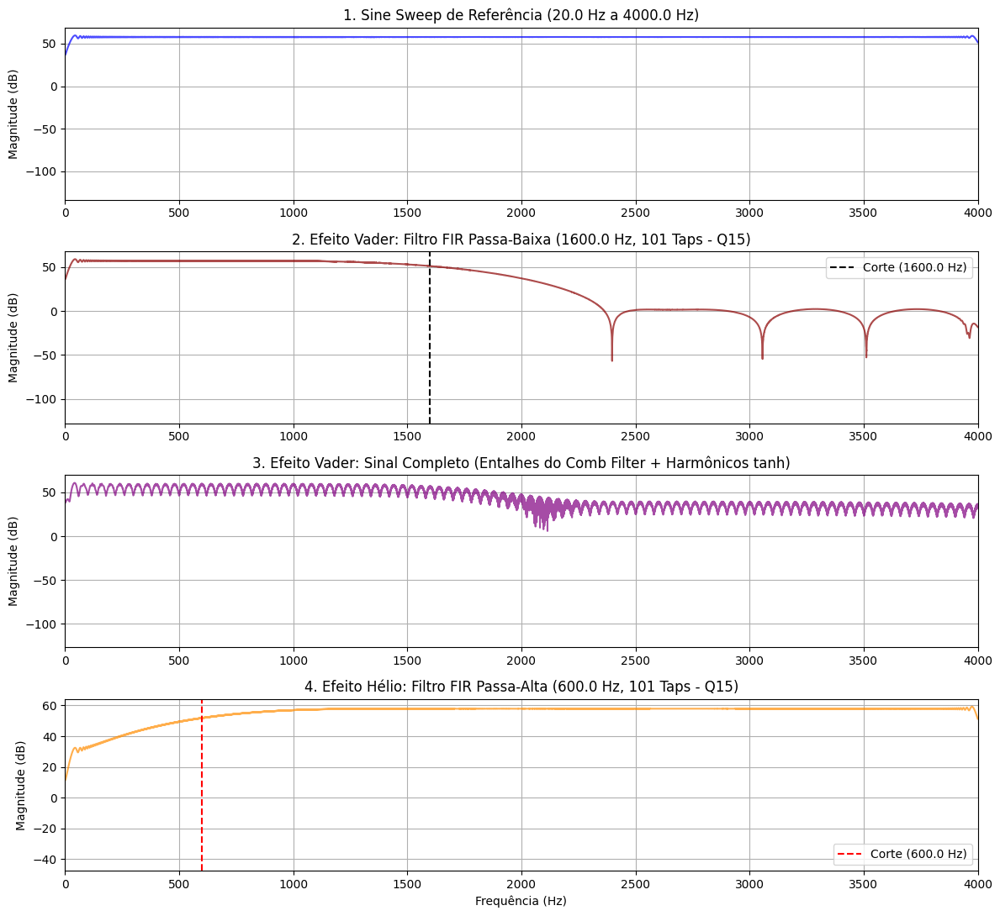


    TABELAS DE COEFICIENTES EM PONTO FIXO (Q15 / 16 BITS)     

// Coeficientes: fir_vader_taps (101 taps, Q15)
const int16_t fir_vader_taps[101] = {
    -15, -17, -18, -19, -19, -18, -15, -11,
    -5, 3, 13, 25, 39, 53, 67, 80,
    90, 95, 95, 88, 73, 49, 17, -24,
    -72, -124, -180, -234, -284, -325, -352, -362,
    -350, -313, -249, -155, -31, 122, 301, 503,
    723, 955, 1192, 1427, 1650, 1856, 2035, 2182,
    2291, 2359, 2381, 2359, 2291, 2182, 2035, 1856,
    1650, 1427, 1192, 955, 723, 503, 301, 122,
    -31, -155, -249, -313, -350, -362, -352, -325,
    -284, -234, -180, -124, -72, -24, 17, 49,
    73, 88, 95, 95, 90, 80, 67, 53,
    39, 25, 13, 3, -5, -11, -15, -18,
    -19, -19, -18, -17, -15
};

// Coeficientes: fir_helio_taps (101 taps, Q15)
const int16_t fir_helio_taps[101] = {
    15, 15, 15, 15, 15, 15, 15, 15,
    15, 14, 12, 9, 6, 1, -5, -12,
    -21, -32, -44, -59, -75, -94, -115, -138,
    -163, -190, -219, -250, -283, -317, -352, -389,
    -426, -464, -502, -540, 

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# ==============================================================================
# SINAL DE TESTE: SINE SWEEP LINEAR (CHIRP)
# ==============================================================================
fs = 44100          # Taxa de amostragem padrão (44.1 kHz)
duracao = 5.0       # Duração de 5 segundos
t = np.linspace(0, duracao, int(fs * duracao), endpoint=False)

f_inicio = 20.0     # Início nos subgraves
f_fim = 4000.0      # Topo da faixa vocal audível

# Gera a varredura linear de 20 Hz a 4000 Hz
sweep = signal.chirp(t, f0=f_inicio, t1=duracao, f1=f_fim, method='linear')

print(f"🎧 SINAL BASE: Sine Sweep Puro ({f_inicio} Hz -> {f_fim} Hz)")
display(Audio(sweep, rate=fs))

# Configurações de hardware compartilhadas
num_taps = 101       # 101 Taps (Ordem 100, Tipo I -> Ímpar obrigatório para passa-alta)
fator_escala = 32768 # Formato Q15 (16 bits com sinal)

# ==============================================================================
# PIPELINE 1: EFEITO DARTH VADER (ETAPA A ETAPA)
# ==============================================================================
print("\n" + "="*60)
print("             PIPELINE 1: DARTH VADER (101 TAPS)                 ")
print("="*60)

# Etapa 2.1: Filtro FIR Passa-Baixa (1600 Hz)
fc_vader = 1600.0
fir_vader = signal.firwin(num_taps, fc_vader, fs=fs, pass_zero='lowpass')
fir_vader_q = np.round(fir_vader * fator_escala) / fator_escala

vader_filtrado = signal.lfilter(fir_vader_q, 1.0, sweep)
vader_filtrado = vader_filtrado / np.max(np.abs(vader_filtrado))

print("\n🎧 VADER - Etapa 2: Passa-Baixa (Som silencia ao cruzar 1600 Hz)")
display(Audio(vader_filtrado, rate=fs))

# Etapa 3.1: Saturação Suave (Soft Clipping / LUT tanh)
ganho_vader = 2.0
vader_sat = np.tanh(vader_filtrado * ganho_vader) * 0.6

print("\n🎧 VADER - Etapa 3: Saturação Suave (Harmônicos mecânicos)")
display(Audio(vader_sat, rate=fs))

# Etapa 4.1: Ressonância do Capacete (Comb Filter / Atraso de 25 ms)
atraso_ms = 25.0
amostras_atraso = int((atraso_ms / 1000.0) * fs)

vader_comb = np.copy(vader_sat)
vader_comb[amostras_atraso:] += 0.6 * vader_sat[:-amostras_atraso]
vader_comb = vader_comb / np.max(np.abs(vader_comb))

print("\n🎧 VADER - Etapa 4: Efeito Capacete (Cancelamento de fase periódico)")
display(Audio(vader_comb, rate=fs))

# Etapa 5.1: Pitch Down (Clock scaling do Codec WM8731)
taxa_vader = int(fs * 0.88)

print("\n🎧 VADER - Etapa 5: Áudio Final Processado")
display(Audio(vader_comb, rate=taxa_vader))

# ==============================================================================
# PIPELINE 2: EFEITO HÉLIO (ETAPA A ETAPA)
# ==============================================================================
print("\n" + "="*60)
print("               PIPELINE 2: HÉLIO (101 TAPS)                     ")
print("="*60)

# Etapa 2.2: Filtro FIR Passa-Alta (600 Hz)
fc_helio = 600.0
fir_helio = signal.firwin(num_taps, fc_helio, fs=fs, pass_zero=False)
fir_helio_q = np.round(fir_helio * fator_escala) / fator_escala

helio_filtrado = signal.lfilter(fir_helio_q, 1.0, sweep)
helio_filtrado = helio_filtrado / np.max(np.abs(helio_filtrado))

print("\n🎧 HÉLIO - Etapa 2: Passa-Alta (Grave mudo; som surge a partir de 600 Hz)")
display(Audio(helio_filtrado, rate=fs))

# Etapa 3.2: Pitch Up (Aceleração do Clock do Codec WM8731)
taxa_helio = int(fs * 1.80)

print("\n🎧 HÉLIO - Etapa 3: Áudio Final Processado")
display(Audio(helio_filtrado, rate=taxa_helio))

# ==============================================================================
# ANÁLISE ESPECTRAL COMPARATIVA (GRÁFICOS)
# ==============================================================================
N = len(sweep)
freqs = np.fft.fftfreq(N, 1 / fs)[:N // 2]

def calc_db(sinal):
    fft_vals = np.abs(np.fft.fft(sinal))[:N // 2]
    return 20 * np.log10(fft_vals + 1e-10)

plt.figure(figsize=(12, 11))

# 1. Sweep Original
plt.subplot(4, 1, 1)
plt.plot(freqs, calc_db(sweep), color='blue', alpha=0.7)
plt.title(f"1. Sine Sweep de Referência ({f_inicio} Hz a {f_fim} Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 4000)
plt.grid(True)

# 2. Vader Passa-Baixa (101 Taps)
plt.subplot(4, 1, 2)
plt.plot(freqs, calc_db(vader_filtrado), color='darkred', alpha=0.7)
plt.title(f"2. Efeito Vader: Filtro FIR Passa-Baixa ({fc_vader} Hz, {num_taps} Taps - Q15)")
plt.axvline(x=fc_vader, color='black', linestyle='--', label=f'Corte ({fc_vader} Hz)')
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 4000)
plt.legend()
plt.grid(True)

# 3. Vader Final (Saturação + Comb Filter)
plt.subplot(4, 1, 3)
plt.plot(freqs, calc_db(vader_comb), color='purple', alpha=0.7)
plt.title("3. Efeito Vader: Sinal Completo (Entalhes do Comb Filter + Harmônicos tanh)")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 4000)
plt.grid(True)

# 4. Hélio Passa-Alta (101 Taps)
plt.subplot(4, 1, 4)
plt.plot(freqs, calc_db(helio_filtrado), color='darkorange', alpha=0.7)
plt.title(f"4. Efeito Hélio: Filtro FIR Passa-Alta ({fc_helio} Hz, {num_taps} Taps - Q15)")
plt.axvline(x=fc_helio, color='red', linestyle='--', label=f'Corte ({fc_helio} Hz)')
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 4000)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==============================================================================
# EXPORTAÇÃO DOS ARRAYS PARA O VERILOG / NIOS II
# ==============================================================================
def export_c_array(nome, coeffs):
    ints = np.round(coeffs * fator_escala).astype(int)
    print(f"\n// Coeficientes: {nome} ({num_taps} taps, Q15)")
    print(f"const int16_t {nome}[{num_taps}] = {{")
    for i in range(0, num_taps, 8):
        bloco = ", ".join(map(str, ints[i:i+8]))
        virgula = "," if i + 8 < num_taps else ""
        print(f"    {bloco}{virgula}")
    print("};")

print("\n" + "="*60)
print("    TABELAS DE COEFICIENTES EM PONTO FIXO (Q15 / 16 BITS)     ")
print("="*60)
export_c_array("fir_vader_taps", fir_vader)
export_c_array("fir_helio_taps", fir_helio)